Avg reward (last50): 0.6


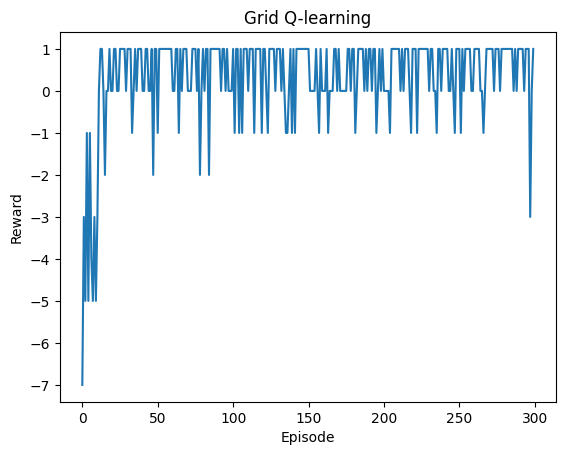

In [ ]:
# exp1_grid_qlearning.py
# Simple GridWorld + Tabular Q-learning demonstration
import random, numpy as np
import matplotlib.pyplot as plt

class GridWorldEnv:
    def __init__(self, rows=4, cols=4, start=(0,0), goal=(3,3)):
        self.rows, self.cols = rows, cols
        self.start, self.goal = start, goal
        self.reset()
    def reset(self):
        self.pos = self.start
        return self.pos
    def step(self, action):
        r,c = self.pos
        if action==0: r2,c2 = r-1,c
        elif action==1: r2,c2 = r,c+1
        elif action==2: r2,c2 = r+1,c
        elif action==3: r2,c2 = r,c-1
        else: raise ValueError
        if 0<=r2<self.rows and 0<=c2<self.cols:
            self.pos = (r2,c2)
            if self.pos==self.goal: return self.pos, 1.0, True, {}
            return self.pos, 0.0, False, {}
        else:
            return self.pos, -1.0, False, {}

def run_grid_q_learning(episodes=300, alpha=0.5, gamma=0.9, eps=0.2):
    env = GridWorldEnv()
    def idx(s): return s[0]*env.cols + s[1]
    n_states = env.rows*env.cols
    Q = np.zeros((n_states, 4))
    rewards = []
    for ep in range(episodes):
        s = env.reset(); total=0
        for t in range(50):
            si = idx(s)
            if random.random() < eps: a = random.randrange(4)
            else: a = int(np.argmax(Q[si]))
            s2, r, done, _ = env.step(a)
            si2 = idx(s2)
            Q[si,a] += alpha*(r + gamma*np.max(Q[si2]) - Q[si,a])
            total += r
            s = s2
            if done: break
        rewards.append(total)
    print("Avg reward (last50):", np.mean(rewards[-50:]))
    plt.plot(rewards); plt.xlabel("Episode"); plt.ylabel("Reward"); plt.title("Grid Q-learning")
    plt.show()
    return Q, rewards

if __name__=="__main__":
    Q, rewards = run_grid_q_learning()


In [ ]:
# exp2_traffic_env.py
import numpy as np

class TrafficIntersectionEnv:
    def __init__(self, max_queue=20, arrival_rates=(0.2,0.2,0.2,0.2), pass_rate=1, seed=None):
        self.max_queue = max_queue
        self.arrival_rates = np.array(arrival_rates, dtype=float)
        self.pass_rate = pass_rate
        self.rng = np.random.RandomState(seed)
        self.reset()
    def reset(self):
        self.queues = np.zeros(4, dtype=int)
        self.t = 0
        return tuple(self.queues)
    def step(self, action):
        # action: 0 -> NS green, 1 -> EW green
        if action==0:
            for lane in (0,2): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        elif action==1:
            for lane in (1,3): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        else:
            raise ValueError
        arrivals = self.rng.poisson(self.arrival_rates)
        self.queues = np.minimum(self.queues + arrivals, self.max_queue)
        self.t += 1
        reward = -float(self.queues.sum())
        return tuple(self.queues), reward, False, {}
    def render(self):
        print(f"t={self.t} queues N,E,S,W = {self.queues}")

if __name__=="__main__":
    env = TrafficIntersectionEnv(arrival_rates=(0.2,0.05,0.2,0.05), pass_rate=2, seed=1)
    s = env.reset()
    for step in range(10):
        a = 0 if step%2==0 else 1
        s, r, done, _ = env.step(a)
        env.render()


t=1 queues N,E,S,W = [0 0 0 0]
t=2 queues N,E,S,W = [0 0 0 0]
t=3 queues N,E,S,W = [0 0 0 0]
t=4 queues N,E,S,W = [0 0 0 0]
t=5 queues N,E,S,W = [0 0 0 0]
t=6 queues N,E,S,W = [0 1 0 0]
t=7 queues N,E,S,W = [1 1 0 0]
t=8 queues N,E,S,W = [1 0 1 0]
t=9 queues N,E,S,W = [0 0 1 0]
t=10 queues N,E,S,W = [1 0 1 0]


Avg reward (last50): -72.28


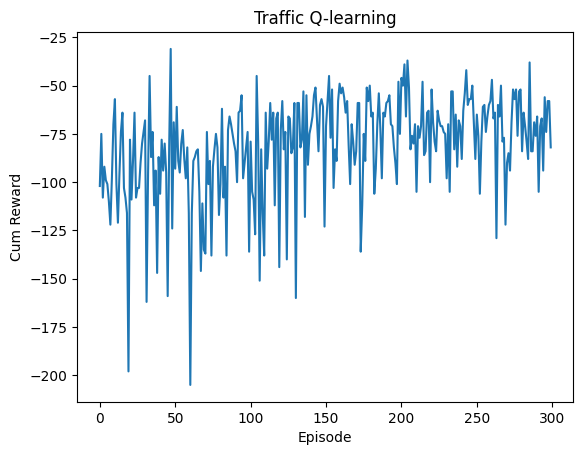

In [ ]:
# exp3_traffic_qlearning.py
# Tabular Q-learning agent controlling the TrafficIntersectionEnv
import random, numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

class TrafficIntersectionEnv:
    def __init__(self, max_queue=20, arrival_rates=(0.2,0.2,0.2,0.2), pass_rate=1, seed=None):
        self.max_queue = max_queue
        self.arrival_rates = np.array(arrival_rates, dtype=float)
        self.pass_rate = pass_rate
        self.rng = np.random.RandomState(seed)
        self.reset()
    def reset(self):
        self.queues = np.zeros(4, dtype=int)
        self.t = 0
        return tuple(self.queues)
    def step(self, action):
        # action: 0 -> NS green, 1 -> EW green
        if action==0:
            for lane in (0,2): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        elif action==1:
            for lane in (1,3): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        else:
            raise ValueError
        arrivals = self.rng.poisson(self.arrival_rates)
        self.queues = np.minimum(self.queues + arrivals, self.max_queue)
        self.t += 1
        reward = -float(self.queues.sum())
        return tuple(self.queues), reward, False, {}
class QLearningAgent:
    def __init__(self, actions=[0,1], alpha=0.1, gamma=0.95, eps=0.2):
        self.Q = defaultdict(lambda: np.zeros(len(actions)))
        self.actions = actions
        self.alpha = alpha; self.gamma = gamma; self.eps = eps
    def get_action(self, state):
        if random.random() < self.eps: return random.choice(self.actions)
        return int(np.argmax(self.Q[state]))
    def update(self, s,a,r,s2):
        q = self.Q[s][a]
        q_next = 0.0 if s2 is None else np.max(self.Q[s2])
        self.Q[s][a] += self.alpha*(r + self.gamma*q_next - q)

def run_traffic_q_learning(episodes=300, steps_per_ep=100):
    env = TrafficIntersectionEnv(arrival_rates=(0.12,0.12,0.12,0.12))
    agent = QLearningAgent()
    rewards=[]
    for ep in range(episodes):
        s = env.reset(); total=0
        for t in range(steps_per_ep):
            a = agent.get_action(s)
            s2, r, _, _ = env.step(a)
            agent.update(s,a,r,s2)
            total += r
            s = s2
        rewards.append(total)
    print("Avg reward (last50):", np.mean(rewards[-50:]))
    plt.plot(rewards); plt.title("Traffic Q-learning"); plt.xlabel("Episode"); plt.ylabel("Cum Reward"); plt.show()
    return agent, rewards

if __name__=="__main__":
    agent, rewards = run_traffic_q_learning()


params (0.05, 0.8, 0.05) avg last20: -80.6
params (0.05, 0.8, 0.2) avg last20: -75.75
params (0.05, 0.95, 0.05) avg last20: -107.65
params (0.05, 0.95, 0.2) avg last20: -106.85
params (0.1, 0.8, 0.05) avg last20: -83.1
params (0.1, 0.8, 0.2) avg last20: -76.55
params (0.1, 0.95, 0.05) avg last20: -90.15
params (0.1, 0.95, 0.2) avg last20: -76.8
Best params: (0.05, 0.8, 0.2) score -75.75


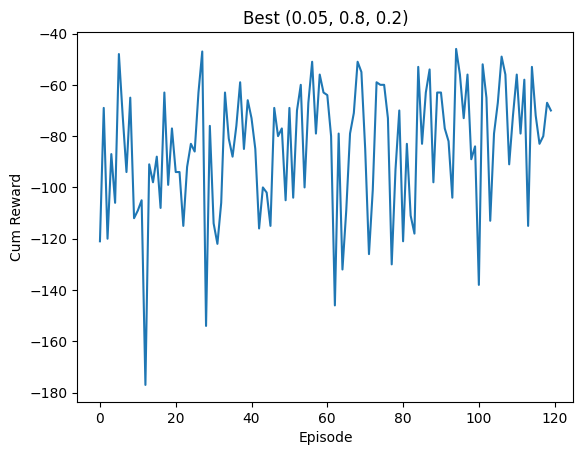

In [ ]:
# exp4_q_hyperparam_search.py
# Grid search across alpha/gamma/epsilon for traffic Q-learning (short runs)
import numpy as np
import matplotlib.pyplot as plt

class QLearningAgent:
    def __init__(self, actions=[0,1], alpha=0.1, gamma=0.95, eps=0.2):
        self.Q = defaultdict(lambda: np.zeros(len(actions)))
        self.actions = actions
        self.alpha = alpha; self.gamma = gamma; self.eps = eps
    def get_action(self, state):
        if random.random() < self.eps: return random.choice(self.actions)
        return int(np.argmax(self.Q[state]))
    def update(self, s,a,r,s2):
        q = self.Q[s][a]
        q_next = 0.0 if s2 is None else np.max(self.Q[s2])
        self.Q[s][a] += self.alpha*(r + self.gamma*q_next - q)

def run_traffic_q_learning(episodes=300, steps_per_ep=100):
    env = TrafficIntersectionEnv(arrival_rates=(0.12,0.12,0.12,0.12))
    agent = QLearningAgent()
    rewards=[]
    for ep in range(episodes):
        s = env.reset(); total=0
        for t in range(steps_per_ep):
            a = agent.get_action(s)
            s2, r, _, _ = env.step(a)
            agent.update(s,a,r,s2)
            total += r
            s = s2
        rewards.append(total)
class TrafficIntersectionEnv:
    def __init__(self, max_queue=20, arrival_rates=(0.2,0.2,0.2,0.2), pass_rate=1, seed=None):
        self.max_queue = max_queue
        self.arrival_rates = np.array(arrival_rates, dtype=float)
        self.pass_rate = pass_rate
        self.rng = np.random.RandomState(seed)
        self.reset()
    def reset(self):
        self.queues = np.zeros(4, dtype=int)
        self.t = 0
        return tuple(self.queues)
    def step(self, action):
        # action: 0 -> NS green, 1 -> EW green
        if action==0:
            for lane in (0,2): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        elif action==1:
            for lane in (1,3): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        else:
            raise ValueError
        arrivals = self.rng.poisson(self.arrival_rates)
        self.queues = np.minimum(self.queues + arrivals, self.max_queue)
        self.t += 1
        reward = -float(self.queues.sum())
        return tuple(self.queues), reward, False, {}
def quick_search():
    alphas=[0.05,0.1]
    gammas=[0.8,0.95]
    epsilons=[0.05,0.2]
    results={}
    for a in alphas:
        for g in gammas:
            for e in epsilons:
                env = TrafficIntersectionEnv(arrival_rates=(0.15,0.15,0.15,0.15))
                agent = QLearningAgent(alpha=a,gamma=g,eps=e)
                rewards=[]
                for ep in range(120):
                    s = env.reset(); total=0
                    for t in range(80):
                        act = agent.get_action(s)
                        s2, r, _, _ = env.step(act)
                        agent.update(s,act,r,s2)
                        total += r; s=s2
                    rewards.append(total)
                results[(a,g,e)] = rewards
                print("params", (a,g,e), "avg last20:", np.mean(rewards[-20:]))
    # pick best
    avg_scores = {k: np.mean(v[-20:]) for k,v in results.items()}
    best = max(avg_scores, key=avg_scores.get)
    print("Best params:", best, "score", avg_scores[best])
    plt.plot(results[best]); plt.title(f"Best {best}"); plt.xlabel("Episode"); plt.ylabel("Cum Reward"); plt.show()

if __name__=="__main__":
    quick_search()


Ep 50/200 reward -172.00 eps 0.778
Ep 100/200 reward -223.00 eps 0.606
Ep 150/200 reward -166.00 eps 0.471
Ep 200/200 reward -103.00 eps 0.367


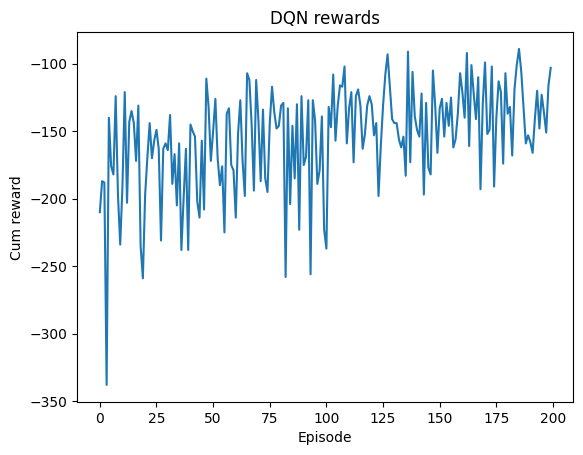

In [ ]:
# exp5_traffic_dqn.py
# DQN training for the traffic environment
import random, numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from collections import deque, namedtuple

class TrafficIntersectionEnv:
    def __init__(self, max_queue=20, arrival_rates=(0.2,0.2,0.2,0.2), pass_rate=1, seed=None):
        self.max_queue = max_queue
        self.arrival_rates = np.array(arrival_rates, dtype=float)
        self.pass_rate = pass_rate
        self.rng = np.random.RandomState(seed)
        self.reset()
    def reset(self):
        self.queues = np.zeros(4, dtype=int)
        self.t = 0
        return tuple(self.queues)
    def step(self, action):
        # action: 0 -> NS green, 1 -> EW green
        if action==0:
            for lane in (0,2): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        elif action==1:
            for lane in (1,3): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        else:
            raise ValueError
        arrivals = self.rng.poisson(self.arrival_rates)
        self.queues = np.minimum(self.queues + arrivals, self.max_queue)
        self.t += 1
        reward = -float(self.queues.sum())
        return tuple(self.queues), reward, False, {}
# Simple feedforward Net
class DQNetwork(nn.Module):
    def __init__(self, input_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim,64), nn.ReLU(), nn.Linear(64,64), nn.ReLU(), nn.Linear(64,n_actions))
    def forward(self,x): return self.net(x)

Transition = namedtuple('Transition',('s','a','r','s2','d'))
class ReplayBuffer:
    def __init__(self, cap=5000): self.buf = deque(maxlen=cap)
    def push(self,*args): self.buf.append(Transition(*args))
    def sample(self,n): import random; batch = random.sample(self.buf,n); return Transition(*zip(*batch))
    def __len__(self): return len(self.buf)

class DQNAgent:
    def __init__(self, state_dim=4, n_actions=2, lr=1e-3, gamma=0.99, batch=64):
        self.device = torch.device("cpu")
        self.policy = DQNetwork(state_dim,n_actions).to(self.device)
        self.target = DQNetwork(state_dim,n_actions).to(self.device)
        self.target.load_state_dict(self.policy.state_dict())
        self.opt = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma = gamma; self.batch=batch; self.replay=ReplayBuffer()
    def act(self, state, eps=0.1):
        if random.random() < eps: return random.randrange(2)
        with torch.no_grad():
            s = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
            return int(torch.argmax(self.policy(s)).item())
    def push(self,*args): self.replay.push(*args)
    def optimize(self):
        if len(self.replay) < self.batch: return
        trans = self.replay.sample(self.batch)
        s = torch.tensor(np.array(trans.s), dtype=torch.float32)
        a = torch.tensor(trans.a).unsqueeze(1)
        r = torch.tensor(trans.r, dtype=torch.float32).unsqueeze(1)
        s2 = torch.tensor(np.array(trans.s2), dtype=torch.float32)
        d = torch.tensor(trans.d, dtype=torch.float32).unsqueeze(1)
        q = self.policy(s).gather(1,a)
        with torch.no_grad():
            qnext = self.target(s2).max(1)[0].unsqueeze(1)
            target = r + (1-d)*self.gamma*qnext
        loss = nn.MSELoss()(q, target)
        self.opt.zero_grad(); loss.backward(); self.opt.step()
    def update_target(self): self.target.load_state_dict(self.policy.state_dict())

def state_to_vec(state): s = np.array(state,dtype=np.float32); return s/(s.max()+1e-6)

def train_dqn(env, episodes=200, steps=100):
    agent = DQNAgent()
    eps = 1.0
    rewards=[]
    for ep in range(episodes):
        s = env.reset(); total=0
        for t in range(steps):
            sv = state_to_vec(s)
            a = agent.act(sv, eps)
            s2, r, _, _ = env.step(a)
            sv2 = state_to_vec(s2)
            agent.push(sv,a,r,sv2,False)
            agent.optimize()
            total += r; s = s2
        eps = max(0.05, eps*0.995)
        if ep%10==0: agent.update_target()
        rewards.append(total)
        if (ep+1)%50==0: print(f"Ep {ep+1}/{episodes} reward {total:.2f} eps {eps:.3f}")
    plt.plot(rewards); plt.title("DQN rewards"); plt.xlabel("Episode"); plt.ylabel("Cum reward"); plt.show()
    return agent, rewards

if __name__=="__main__":
    env = TrafficIntersectionEnv(arrival_rates=(0.18,0.18,0.18,0.18), pass_rate=1, seed=1)
    agent, rewards = train_dqn(env, episodes=200, steps=100)


In [ ]:
# exp6_dynamic_density.py
# Train Q-learning per density and evaluate.
import numpy as np
import random
from collections import defaultdict

class TrafficIntersectionEnv:
    def __init__(self, max_queue=20, arrival_rates=(0.2,0.2,0.2,0.2), pass_rate=1, seed=None):
        self.max_queue = max_queue
        self.arrival_rates = np.array(arrival_rates, dtype=float)
        self.pass_rate = pass_rate
        self.rng = np.random.RandomState(seed)
        self.reset()
    def reset(self):
        self.queues = np.zeros(4, dtype=int)
        self.t = 0
        return tuple(self.queues)
    def step(self, action):
        # action: 0 -> NS green, 1 -> EW green
        if action==0:
            for lane in (0,2): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        elif action==1:
            for lane in (1,3): self.queues[lane] = max(0, self.queues[lane]-self.pass_rate)
        else:
            raise ValueError
        arrivals = self.rng.poisson(self.arrival_rates)
        self.queues = np.minimum(self.queues + arrivals, self.max_queue)
        self.t += 1
        reward = -float(self.queues.sum())
        return tuple(self.queues), reward, False, {}

class QLearningAgent:

    def __init__(self, actions=[0,1], alpha=0.1, gamma=0.95, eps=0.2):
        self.Q = defaultdict(lambda: np.zeros(len(actions)))
        self.actions = actions
        self.alpha = alpha; self.gamma = gamma; self.eps = eps
    def get_action(self, state):
        if random.random() < self.eps: return random.choice(self.actions)
        return int(np.argmax(self.Q[state]))
    def update(self, s,a,r,s2):
        q = self.Q[s][a]
        q_next = 0.0 if s2 is None else np.max(self.Q[s2])
        self.Q[s][a] += self.alpha*(r + self.gamma*q_next - q)

def run_traffic_q_learning(episodes=300, steps_per_ep=100):
    env = TrafficIntersectionEnv(arrival_rates=(0.12,0.12,0.12,0.12))
    agent = QLearningAgent()
    rewards=[]
    for ep in range(episodes):
        s = env.reset(); total=0
        for t in range(steps_per_ep):
            a = agent.get_action(s)
            s2, r, _, _ = env.step(a)
            agent.update(s,a,r,s2)
            total += r
            s = s2
        rewards.append(total)

def train_q_on_env(env, episodes=120, steps_per_ep=80):
    agent = QLearningAgent()
    rewards=[]
    for ep in range(episodes):
        s = env.reset(); total=0
        for t in range(steps_per_ep):
            a = agent.get_action(s)
            s2, r, _, _ = env.step(a)
            agent.update(s,a,r,s2)
            total += r; s = s2
        rewards.append(total)
    return agent, rewards

def dynamic_test(densities=[0.05,0.15,0.3]):
    results={}
    for d in densities:
        print("Density:", d)
        env = TrafficIntersectionEnv(arrival_rates=(d,d,d,d))
        agent, train_rewards = train_q_on_env(env, episodes=120, steps_per_ep=80)
        # evaluate
        env_eval = TrafficIntersectionEnv(arrival_rates=(d,d,d,d), seed=42)
        s = env_eval.reset(); total=0
        for t in range(80):
            a = agent.get_action(s)
            s, r, _, _ = env_eval.step(a)
            total += r
        print("Eval cumulative reward:", total)
        results[d] = dict(train=train_rewards, eval=total)
    return results

if __name__=="__main__":
    res = dynamic_test([0.05,0.15,0.3])

Density: 0.05
Eval cumulative reward: -13.0
Density: 0.15
Eval cumulative reward: -183.0
Density: 0.3
Eval cumulative reward: -382.0


Agent 0 avg reward last50: -1.34


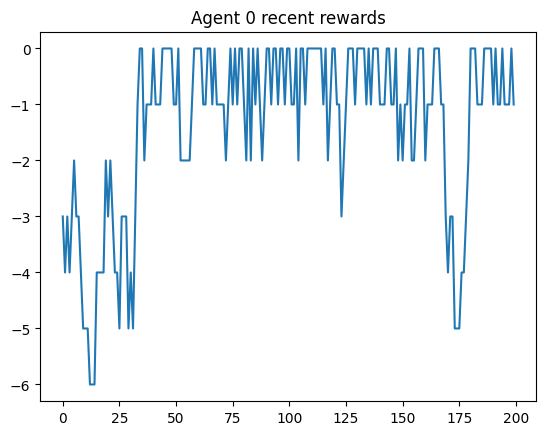

Agent 1 avg reward last50: -0.7


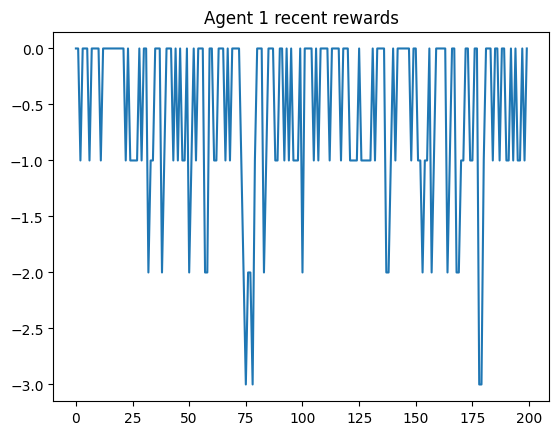

Agent 2 avg reward last50: -0.9


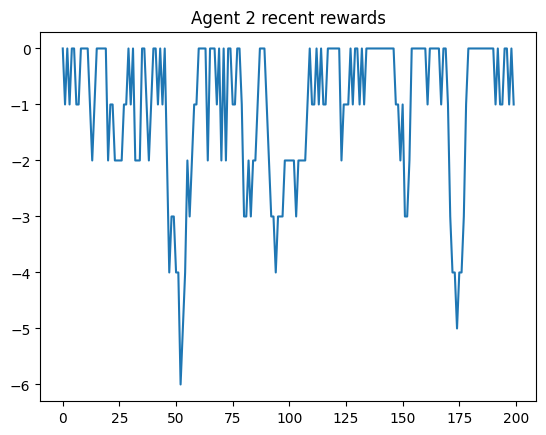

In [ ]:
# exp7_multiagent_q.py
# Simple independent multi-agent Q-learning on chain of intersections
import numpy as np
from collections import defaultdict
import random
import matplotlib.pyplot as plt

# Minimal MultiAgentEnv (toy chain)
class MultiAgentEnv:
    def __init__(self, n=3, arrival_rate=0.15, pass_rate=1, max_queue=20, seed=None):
        self.n = n
        self.arrival_rate = arrival_rate
        self.pass_rate = pass_rate
        self.max_queue = max_queue
        self.rng = np.random.RandomState(seed)
        self.reset()
    def reset(self):
        self.queues = np.zeros((self.n,4), dtype=int)
        return [tuple(self.queues[i]) for i in range(self.n)]
    def step(self, actions):
        # actions: list of length n
        for i,a in enumerate(actions):
            if a==0:
                for lane in (0,2): self.queues[i,lane] = max(0,self.queues[i,lane]-self.pass_rate)
            else:
                for lane in (1,3): self.queues[i,lane] = max(0,self.queues[i,lane]-self.pass_rate)
        # simple local arrivals
        arrivals = self.rng.poisson(self.arrival_rate, size=(self.n,4))
        self.queues = np.minimum(self.queues + arrivals, self.max_queue)
        rewards = [-float(self.queues[i].sum()) for i in range(self.n)]
        return [tuple(self.queues[i]) for i in range(self.n)], rewards, False, {}

class QAgent:
    def __init__(self, alpha=0.1, gamma=0.95, eps=0.2):
        self.Q = defaultdict(lambda: np.zeros(2))
        self.alpha, self.gamma, self.eps = alpha, gamma, eps
    def act(self, state):
        if random.random() < self.eps: return random.choice([0,1])
        return int(np.argmax(self.Q[state]))
    def update(self,s,a,r,s2):
        q = self.Q[s][a]
        qnext = np.max(self.Q[s2])
        self.Q[s][a] += self.alpha*(r + self.gamma*qnext - q)

def run_multi(n=3, episodes=200, steps=80, arrival_rate=0.12):
    env = MultiAgentEnv(n=n, arrival_rate=arrival_rate)
    agents = [QAgent() for _ in range(n)]
    all_rewards = [[] for _ in range(n)]
    for ep in range(episodes):
        states = env.reset()
        for t in range(steps):
            actions = [agents[i].act(states[i]) for i in range(n)]
            next_states, rewards, _, _ = env.step(actions)
            for i in range(n):
                agents[i].update(states[i], actions[i], rewards[i], next_states[i])
                all_rewards[i].append(rewards[i])
            states = next_states
    for i in range(n):
        print(f"Agent {i} avg reward last50:", np.mean(all_rewards[i][-50:]))
        plt.plot(all_rewards[i][-200:]); plt.title(f"Agent {i} recent rewards"); plt.show()
    return agents, all_rewards

if __name__=="__main__":
    agents, rewards = run_multi(n=3, episodes=250, steps=80)
